# Random Forest: Ensemble Learning

A Random Forest reduces variance by training multiple trees on different subsets of the data (Bagging).

### Why it's better than a single Tree:
1. **Diversity**: Each tree sees different data and different features.
2. **Stability**: Noise in one tree is canceled out by the others.

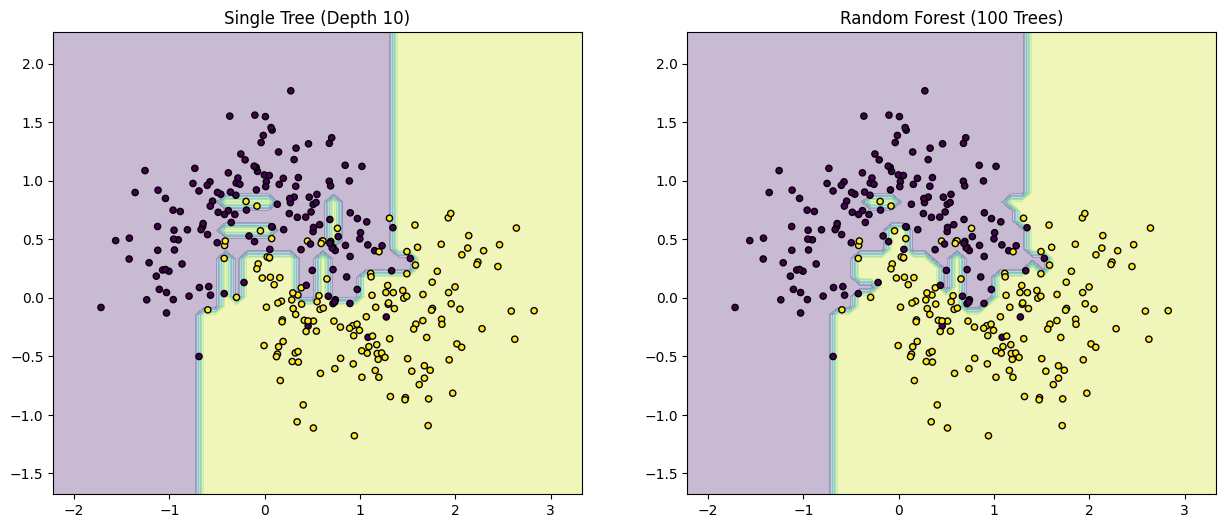

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage.supervised_learning import RandomForest
from sklearn.datasets import make_moons

# 1. Generate Data
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# 2. Compare Tree vs Forest
# Note: Since DecisionTree is in your init, you can compare them easily
from mlpackage.supervised_learning import DecisionTree

models = [
    ("Single Tree (Depth 10)", DecisionTree(max_depth=10)),
    ("Random Forest (100 Trees)", RandomForest(n_trees=100, max_depth=10))
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, model) in enumerate(models):
    model.fit(X, y)
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
    axes[i].set_title(name)

plt.show()